---

# **INTRODUCTION**

---

The dataset used in this study provides a detailed view of global energy consumption, economic activity, and environmental performance. It includes indicators such as primary energy use, renewable energy share, fossil fuel dependence, electricity access, and GDP per capita factors that directly shape a country’s CO₂ emission patterns. With its broad coverage across countries and years, the dataset serves as a reliable foundation for understanding how different energy systems contribute to global carbon output.

Because the dataset contains multiple interacting variables, it is well-suited for machine-learning analysis. These features allow models to capture complex nonlinear relationships that traditional statistical methods often overlook. Through preprocessing, feature scaling, and model training, the dataset enables accurate emission prediction and classification, supporting the development of tools like Sustainalyze that enhance sustainability analytics and climate-related decision-making.

---


# **DATA PREPROCESSING**

---

Data preprocessing stage, several essential steps were carried out to ensure that the dataset was clean, reliable, and ready for analysis. The process began with preparing and examining the dataset to understand its structure and identify potential issues. Missing values were then addressed through either imputation or removal, depending on the nature of the data. Duplicate entries were checked and eliminated to avoid redundancy and potential bias. Feature preparation was also performed, transforming and refining variables to enhance their suitability for modeling. Correlation analysis followed, allowing the identification of significant relationships between features and the reduction of multicollinearity. After all preprocessing procedures were completed, the cleaned dataset was stored to support consistent and reproducible work in the subsequent phases of the study.

## **LOAD AND PREPARE THE DATASET**

To start working with the data required for the project, the first step in the process is preprocessing, which ensures that the dataset is clean, organized, and ready for later stages such as model training and analysis. The code begins by importing essential Python libraries that support data handling, numerical computation, and visualization. After preparing these tools, the dataset "global-data-on-sustainable-energy.csv", which contains indicators related to sustainable energy and CO₂ emissions, is loaded into a pandas dataframe. Once the data is successfully loaded, its shape, structure, and data types are examined using functions like df.info() and df.head(). This helps the researchers understand what variables are available and whether the dataset contains missing or inconsistent values that may affect the analysis. As part of the preprocessing, a long and complex column name, Value_co2_emissions_kt_by_country, is also renamed to a simpler and clearer label, Co2_emission, which improves readability and helps maintain consistency throughout the study. This entire step lays the foundation for the upcoming modeling phase by ensuring the dataset is properly prepared and easier to work with.

In [ ]:
# --- Libraries ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import re

# --- Load Dataset ---
df = pd.read_csv("/content/global-data-on-sustainable-energy.csv")
print("✅ Dataset Loaded. Shape:", df.shape)

# Show basic information about the dataset
print("\n📌 DATASET INFO:")
df.info()

# Preview the first rows
df.head()

df = df.rename(columns={"Value_co2_emissions_kt_by_country": "Co2_emission"})






✅ Dataset Loaded. Shape: (3649, 21)

📌 DATASET INFO:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 21 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Entity                                                            3649 non-null   object 
 1   Year                                                              3649 non-null   int64  
 2   Access to electricity (% of population)                           3639 non-null   float64
 3   Access to clean fuels for cooking                                 3480 non-null   float64
 4   Renewable-electricity-generating-capacity-per-capita              2718 non-null   float64
 5   Financial flows to developing countries (US $)                    1560 non-null   float64
 6   Renewable energy share in the total final energy consumption (%)  3455 non-

As part of the preprocessing stage, columns that are not relevant to the focus of the study are removed to simplify the dataset and improve the quality of the analysis. Specifically, the Entity column is dropped because this research does not focus on country-specific results, and the Year column is removed because the dataset spans from 2000 to 2020 for each country, which is not needed for the prediction and modeling tasks. By eliminating these columns, the analysis can concentrate on the key features, such as CO₂ emissions and other sustainable energy indicators, without unnecessary information that could complicate the model. After this step, the remaining columns are displayed to confirm that only the relevant data is retained. This ensures the dataset is cleaner, more focused, and ready for subsequent scaling, feature preparation, and model training.

In [ ]:
  df = df.drop(columns=['Entity', 'Year'], errors='ignore')
  print("\n✅ Dropped 'Entity' and 'Year' columns.")
  print("Remaining columns:", df.columns.tolist())



✅ Dropped 'Entity' and 'Year' columns.
Remaining columns: ['Access to electricity (% of population)', 'Access to clean fuels for cooking', 'Renewable-electricity-generating-capacity-per-capita', 'Financial flows to developing countries (US $)', 'Renewable energy share in the total final energy consumption (%)', 'Electricity from fossil fuels (TWh)', 'Electricity from nuclear (TWh)', 'Electricity from renewables (TWh)', 'Low-carbon electricity (% electricity)', 'Primary energy consumption per capita (kWh/person)', 'Energy intensity level of primary energy (MJ/$2017 PPP GDP)', 'Co2_emission', 'Renewables (% equivalent primary energy)', 'gdp_growth', 'gdp_per_capita', 'Density_(P/Km2)', 'Land Area(Km2)', 'Latitude', 'Longitude']


## HANDLING MISSING VALUES

The next step in preprocessing is to examine the dataset for missing values, which could negatively impact the accuracy and reliability of the predictive models. The code calculates the total number of missing entries in each column using df.isnull().sum() and then converts these counts into percentages relative to the total number of rows. This provides a clear picture of the proportion of missing data for each feature. To aid interpretation, a bar chart is generated showing the percentage of missing values for columns that contain any gaps in the data. This visualization allows the researchers to quickly identify which columns may require imputation, removal, or further investigation. By addressing missing values at this stage, the dataset becomes more complete and consistent, laying the groundwork for effective model training and analysis.


🔎 Missing values per column:
Access to electricity (% of population)                               10
Access to clean fuels for cooking                                    169
Renewable-electricity-generating-capacity-per-capita                 931
Financial flows to developing countries (US $)                      2089
Renewable energy share in the total final energy consumption (%)     194
Electricity from fossil fuels (TWh)                                   21
Electricity from nuclear (TWh)                                       126
Electricity from renewables (TWh)                                     21
Low-carbon electricity (% electricity)                                42
Primary energy consumption per capita (kWh/person)                     0
Energy intensity level of primary energy (MJ/$2017 PPP GDP)          207
Co2_emission                                                         428
Renewables (% equivalent primary energy)                            2137
gdp_growth           

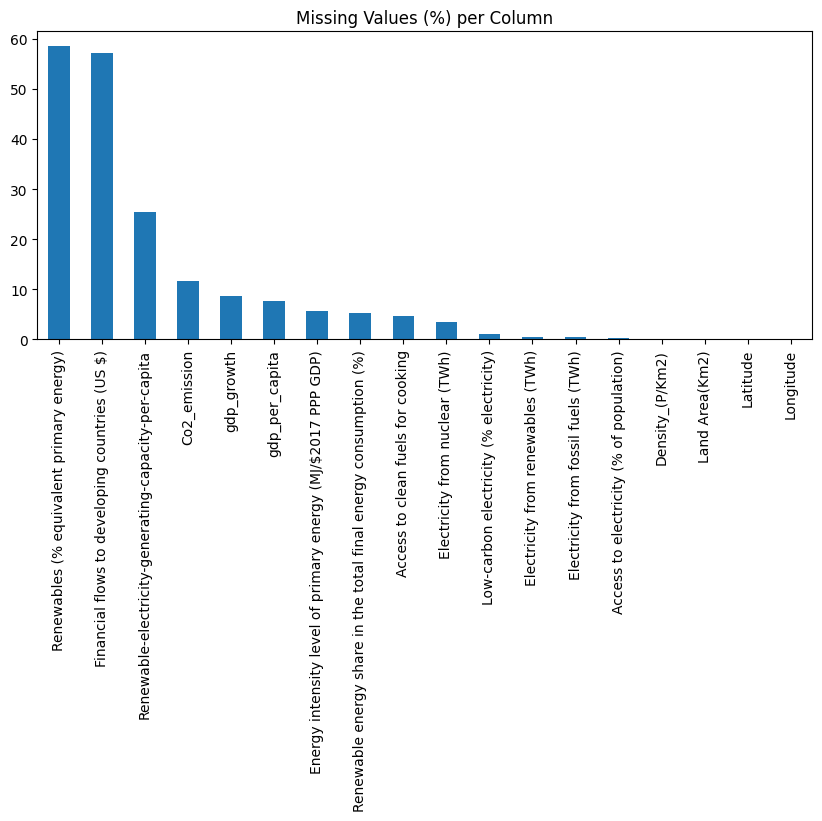

In [ ]:
print("\n🔎 Missing values per column:")
print(df.isnull().sum())
missing_percent = (df.isnull().sum() / len(df)) * 100
plt.figure(figsize=(10,4))
missing_percent[missing_percent > 0].sort_values(ascending=False).plot(kind='bar')
plt.title("Missing Values (%) per Column")
plt.show()


After identifying missing values in the dataset, the next step is to handle these gaps to ensure the data is complete for modeling. In this study, missing values in numeric columns are replaced with the median of each respective column using df.fillna(df.median(numeric_only=True)). The median is chosen because it is less sensitive to outliers compared to the mean, providing a robust estimate for missing entries. By filling missing values in this way, the dataset becomes fully populated, reducing the risk of errors during model training and ensuring that all features can be effectively used in subsequent analysis.

In [ ]:
df = df.fillna(df.median(numeric_only=True))
print("\n✅ Missing values handled (filled with median).")



✅ Missing values handled (filled with median).


## HANDLING DUPLICATES

As part of data cleaning, the dataset is also checked for duplicate rows, which can introduce bias or distort the results of the analysis and model training. The code identifies the number of duplicate entries using df.duplicated().sum() and prints the total count. If any duplicates are found, they are removed using df.drop_duplicates() to ensure that each observation in the dataset is unique. In this case, the removal of duplicates helps maintain data integrity and ensures that the predictive models are trained on accurate and non-redundant information.

In [ ]:
duplicates = df.duplicated().sum()
print(f"\n🔎 Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("✅ Duplicates removed.")
else:
    print("No duplicates found.")



🔎 Duplicate rows: 0
No duplicates found.


## FEATURE PREPARATION

After cleaning the dataset, the next step is to define the features and target variable for modeling. In this study, the target variable Co2_emission is separated from the rest of the dataset, while all remaining columns are treated as input features. Since some feature columns may contain string values with formatting characters such as commas, these are first removed, and the columns are converted to numeric types to ensure they can be used in calculations and model training. Any new missing values created during this conversion are then filled with the median of the respective column to maintain data completeness. To standardize the scale of all features and improve the performance of machine learning models, StandardScaler is applied, which transforms each feature to have a mean of zero and a standard deviation of one. This ensures that features with larger numeric ranges do not disproportionately influence the model. At the end of this step, all input features are numeric, scaled, and ready for model training and prediction

In [ ]:
# Define features and target
X = df.drop(columns=["Co2_emission"])  # drop the target column
y = df["Co2_emission"]

# Convert all object/string columns to numeric (remove commas)
for col in X.columns:
    if X[col].dtype == 'object':
        # Remove commas
        X[col] = X[col].str.replace(",", "", regex=False)
        # Convert to numeric
        X[col] = pd.to_numeric(X[col], errors='coerce')

# Fill NaNs with median
X = X.fillna(X.median(numeric_only=True))

# Scale features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("✅ All features converted to numeric and scaled.")


✅ All features converted to numeric and scaled.


## CHECKING CORRELATION

Following data preprocessing and feature scaling, the next step in the study is to explore the relationship between each feature and the target variable, Co2_emission. This is done by computing the Pearson correlation coefficient for all numeric columns in the dataset, which quantifies the strength and direction of a linear relationship between each feature and CO₂ emissions. The correlation values are sorted from lowest to highest to highlight features with the strongest negative and positive associations. For visualization, a horizontal bar graph is created where features with negative correlations are colored red and those with positive correlations are colored green. This visual representation allows researchers to quickly identify which variables are most strongly related to CO₂ emissions, guiding feature selection and providing insight into potential predictors for modeling. The plot also includes grid lines to improve readability, making it easier to interpret the magnitude of correlations across different features.

🔍 Exact Correlation Values:

Renewable energy share in the total final energy consumption (%)   -0.117424
Low-carbon electricity (% electricity)                             -0.046170
Renewables (% equivalent primary energy)                           -0.006128
Renewable-electricity-generating-capacity-per-capita                0.019933
Longitude                                                           0.039214
gdp_growth                                                          0.042056
Energy intensity level of primary energy (MJ/$2017 PPP GDP)         0.049326
Access to clean fuels for cooking                                   0.080797
gdp_per_capita                                                      0.095284
Primary energy consumption per capita (kWh/person)                  0.096291
Financial flows to developing countries (US $)                      0.102939
Latitude                                                            0.108829
Access to electricity (% of population)        

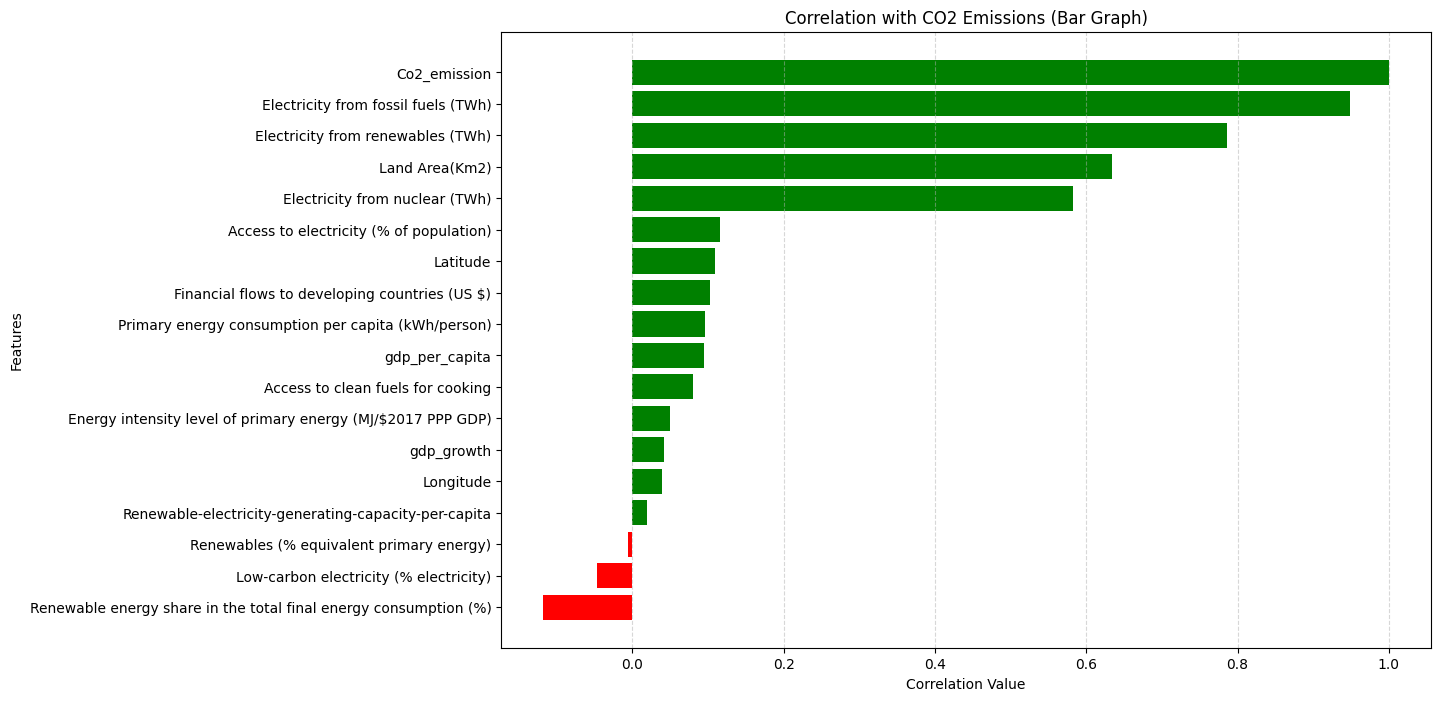

In [ ]:
target="Co2_emission"


# Compute correlation
corr = df.corr(numeric_only=True)[target].sort_values(ascending=True)

print("🔍 Exact Correlation Values:\n")
print(corr)

# Colors: red for negative, green for positive
colors = ['red' if val < 0 else 'green' for val in corr]

plt.figure(figsize=(12, 8))
plt.barh(corr.index, corr.values, color=colors)
plt.title("Correlation with CO2 Emissions (Bar Graph)")
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

## SAVING THE DATASET

After completing all cleaning, transformation, and feature preparation steps, the dataset is now ready for analysis and modeling. To document the final structure, df.info() is used to display the updated column types, counts, and any remaining issues. The cleaned and processed dataset is then saved to a new CSV file named "ENERGY_DATA_CLEANED.csv". Storing this version ensures that all preprocessing steps are preserved, allows for reproducibility, and provides a ready-to-use dataset for subsequent predictive modeling and analysis. This step marks the completion of the data preparation phase, providing a reliable foundation for the research objectives.

In [ ]:
# Save the cleaned dataset
df.info()

df.to_csv("/content/ENERGY_DATA_CLEANED.csv", index=False)
print("✅ Cleaned dataset saved as 'ENERGY_DATA_CLEANED.csv'")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3649 entries, 0 to 3648
Data columns (total 19 columns):
 #   Column                                                            Non-Null Count  Dtype  
---  ------                                                            --------------  -----  
 0   Access to electricity (% of population)                           3649 non-null   float64
 1   Access to clean fuels for cooking                                 3649 non-null   float64
 2   Renewable-electricity-generating-capacity-per-capita              3649 non-null   float64
 3   Financial flows to developing countries (US $)                    3649 non-null   float64
 4   Renewable energy share in the total final energy consumption (%)  3649 non-null   float64
 5   Electricity from fossil fuels (TWh)                               3649 non-null   float64
 6   Electricity from nuclear (TWh)                                    3649 non-null   float64
 7   Electricity from renewables (TWh)

---

# **CHOOSING A RIGHT MODEL (LINEAR REGRESSION, RANDOM FORREST REGRESSION, SVR, GRADIENT BOOSTING) TO TRAIN AND EVALUATE**

---

Selecting an appropriate predictive model is a critical step in ensuring accurate and reliable CO₂ emission forecasting. This phase involves examining different regression algorithms, evaluating their performance using consistent metrics, and identifying which model best captures the relationships within the dataset. Through systematic comparison of baseline and advanced ensemble methods, the process reveals how each algorithm handles complexity, nonlinearity, and generalization. Additional evaluation techniques help determine whether a model is prone to overfitting or underfitting, ensuring that the chosen approach remains stable across unseen data. By grounding model selection in quantitative evidence and methodological rigor, this stage builds a strong foundation for achieving high predictive accuracy and supporting meaningful sustainability analysis.

## LOAD THE DATA

This code represents the initial steps of preparing the cleaned dataset for regression modeling. First, the cleaned dataset "ENERGY_DATA_CLEANED.csv" is loaded into a pandas dataframe. The features (X) and target variable (y_reg) are then defined, with X containing all columns except the target Co2_emission, and y_reg holding the CO₂ emission values to be predicted. Since some feature columns may contain numeric values stored as strings (for example, numbers with commas like "1,234"), the code iterates through all object-type columns and removes commas, then converts the values to numeric types. This ensures that all features are in a proper numeric format, which is necessary for machine learning algorithms to process them correctly.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Load cleaned dataset ---
df = pd.read_csv("/content/ENERGY_DATA_CLEANED.csv")

# --- Features and target ---
X = df.drop(columns=["Co2_emission"])  # only drop CO2 target
y_reg = df["Co2_emission"]

# --- Convert any string numbers to numeric ---
for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = X[col].str.replace(",", "", regex=False)  # remove commas
        X[col] = pd.to_numeric(X[col], errors='coerce')    # convert to numeric


In preparation for training and evaluating machine learning models, the dataset is first finalized to ensure it is ready for modeling. Any remaining missing values in the features are filled with the median, providing a complete dataset and avoiding errors during training. The features are then standardized using StandardScaler, which transforms each feature to have a mean of zero and a standard deviation of one. Standardization is crucial because it ensures that all features contribute equally to the learning process, preventing variables with larger numerical ranges from dominating the model. Finally, the data is split into training and testing sets using an 80-20 split. The training set is used to train and tune multiple candidate models, while the testing set is held out for evaluating model performance on unseen data. This step ensures that the dataset is properly formatted, scaled, and partitioned, providing a solid foundation for selecting the most suitable predictive model.

In [ ]:

# --- Fill missing values ---
X = X.fillna(X.median(numeric_only=True))

# --- Scale features ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# --- Split data into train/test ---
X_train, X_test, y_train_reg, y_test_reg = train_test_split(
    X_scaled, y_reg, test_size=0.2, random_state=42
)

print("✅ Features converted, scaled, and split successfully.")


✅ Features converted, scaled, and split successfully.


## REGRESSION MODELS

Once the dataset is fully prepared and split into training and testing sets, multiple machine learning algorithms are initialized to determine which model is most suitable for predicting CO₂ emissions. Four different regression models are selected for comparison. Linear Regression is a simple and interpretable model that assumes a linear relationship between the features and the target variable. Random Forest Regressor and Gradient Boosting Regressor are ensemble methods that combine multiple decision trees to capture complex, nonlinear relationships and improve prediction accuracy. Support Vector Regressor (SVR) is also included, as it can model nonlinear patterns using kernel functions and is effective in handling high-dimensional feature spaces. By defining these models in a dictionary, the study sets up a framework for systematic training, evaluation, and comparison of different approaches, allowing the researchers to identify the algorithm that provides the best performance for CO₂ emission prediction.

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
import pprint

# Initialize models
reg_models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "SVR": SVR()
}

After initializing the candidate regression models, each model is trained using the training dataset (X_train and y_train_reg). Once trained, predictions are generated for both the training set and the testing set to assess how well the models fit the data and generalize to unseen observations. The performance of each model is quantified using two common metrics: Mean Squared Error (MSE), which measures the average squared difference between predicted and actual CO₂ emission values, and R-squared (R²), which indicates the proportion of variance in the target variable explained by the model. The results for each model, including training and testing MSE and R², are stored in a dictionary (reg_results) for easy comparison. This process allows researchers to systematically evaluate multiple algorithms and select the one that achieves the best balance between accuracy and generalization for predicting CO₂ emissions.

In [ ]:

# Train and evaluate
reg_results = {}
for name, model in reg_models.items():
    model.fit(X_train, y_train_reg)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Store results
    reg_results[name] = {
        "Train MSE": mean_squared_error(y_train_reg, y_train_pred),
        "Train R2": r2_score(y_train_reg, y_train_pred),
        "Test MSE": mean_squared_error(y_test_reg, y_test_pred),
        "Test R2": r2_score(y_test_reg, y_test_pred)
    }

After training and evaluating all candidate regression models, the results are displayed in a clear and organized format. The dictionary reg_results contains the performance metrics, Mean Squared Error (MSE) and R-squared (R²), for both the training and testing datasets for each model. Printing these results allows researchers to compare the models side by side, identify which algorithm performs best in terms of prediction accuracy and generalization, and make informed decisions about which model to select for further analysis or deployment. This step provides a concise summary of model performance, supporting transparent evaluation and reproducibility in the study.

In [ ]:



# Show results
print("📊 Regression Model Results (Train & Test):")
pprint.pprint(reg_results)


📊 Regression Model Results (Train & Test):
{'Gradient Boosting': {'Test MSE': 2161225642.136167,
                       'Test R2': 0.992417070224872,
                       'Train MSE': 353074963.87841845,
                       'Train R2': 0.9994031772448629},
 'Linear Regression': {'Test MSE': 14829134629.7441,
                       'Test R2': 0.9479701312389933,
                       'Train MSE': 55322976281.77387,
                       'Train R2': 0.9064844168949892},
 'Random Forest': {'Test MSE': 2160033299.227655,
                   'Test R2': 0.9924212537087096,
                   'Train MSE': 7334274861.282601,
                   'Train R2': 0.9876024567656672},
 'SVR': {'Test MSE': 295265782657.1708,
         'Test R2': -0.03597683242111227,
         'Train MSE': 611041775186.0701,
         'Train R2': -0.03287877385714033}}


## RANDOM SEARCH TRAINING METHOD FOR GRADIENT BOOSTING TO FIND THE BEST MODEL


After evaluating multiple regression models, Gradient Boosting Regressor was selected as the best-performing model for predicting CO₂ emissions. The next step is to train this model while optimizing its hyperparameters to achieve the highest possible accuracy. To do this, a randomized search approach is used, which explores a predefined range of hyperparameter values by sampling combinations randomly. The hyperparameters considered include the number of trees (n_estimators), learning rate (learning_rate), tree depth (max_depth), minimum samples required to split a node (min_samples_split) and to form a leaf (min_samples_leaf), as well as the fraction of samples used for fitting each tree (subsample). This method allows the model to efficiently search for an optimal set of hyperparameters, improving performance without exhaustively testing all possible combinations. By tuning these hyperparameters, the Gradient Boosting model can better capture patterns in the data and provide more accurate predictions.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# --- Hyperparameter distributions ---
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [2, 3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.6, 0.75, 0.9, 1.0]
}

After defining the range of hyperparameters, the Gradient Boosting Regressor model is initialized with a fixed random state to ensure reproducibility. To find the optimal combination of hyperparameters, a Randomized Search approach is used. RandomizedSearchCV samples a specified number of hyperparameter combinations randomly from the predefined ranges, in this case performing 20 trials. Each combination is evaluated using five-fold cross-validation, which splits the training data into five subsets and tests the model on each subset to assess its generalization performance. The scoring metric used is R-squared, which measures how well the model explains the variance in CO₂ emissions. Parallel computation is enabled with n_jobs=-1 to speed up the search process, and verbose output is included to monitor progress. This procedure ensures that the Gradient Boosting model is trained with a hyperparameter configuration that maximizes predictive accuracy while reducing overfitting.

In [ ]:
# --- Initialize model ---
gbr = GradientBoostingRegressor(random_state=42)

# --- Random Search ---
random_search = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=20,          # number of random trials
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

The Randomized Search is executed by fitting the Gradient Boosting model to the training dataset. The fit method evaluates multiple randomly selected hyperparameter combinations using five-fold cross-validation for each combination. The outcomes of this search, including performance scores and the parameters used for all trials, are stored in cv_results as a pandas dataframe. This allows researchers to examine how different hyperparameter settings affected model performance. A structure is also prepared to build detailed logs of the results for further analysis. Logging these details ensures transparency and reproducibility, making it possible to track which hyperparameters led to the best performance and to document the model selection process in the study.

In [ ]:
# --- Fit Random Search ---
random_search.fit(X_train, y_train_reg)

# --- Extract random search results ---
cv_results = pd.DataFrame(random_search.cv_results_)

# --- Build detailed logs ---
log_rows = []


Each hyperparameter combination from the Randomized Search results is evaluated individually to understand its effect on model performance. For every set of parameters stored in cv_results, a new Gradient Boosting Regressor is instantiated with those specific settings. The model is then trained using the training dataset, and predictions are generated for both the training and testing sets. Performance metrics, including Mean Squared Error (MSE) and R-squared (R²), are calculated for each run and recorded along with the hyperparameters and a unique run identifier. These detailed logs are stored in log_rows to allow systematic comparison of all hyperparameter combinations. This process provides a comprehensive evaluation of how each configuration impacts both training and generalization performance, supporting an informed selection of the optimal model for predicting CO₂ emissions.

In [ ]:

for i, row in cv_results.iterrows():
    params = row['params']
    run_id = i + 1

    # Fit model with this parameter set
    model = GradientBoostingRegressor(random_state=42, **params)
    model.fit(X_train, y_train_reg)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    log_rows.append({
        'Run_ID': run_id,
        **params,
        'Train_MSE': mean_squared_error(y_train_reg, y_train_pred),
        'Train_R2': r2_score(y_train_reg, y_train_pred),
        'Test_MSE': mean_squared_error(y_test_reg, y_test_pred),
        'Test_R2': r2_score(y_test_reg, y_test_pred)
    })

The detailed results of the Randomized Search, including all hyperparameter combinations and their corresponding performance metrics, are compiled into a dataframe and saved to an Excel file. This ensures that the evaluation process is well-documented, transparent, and reproducible. The best hyperparameter set identified by the Randomized Search is then retrieved, along with the corresponding trained Gradient Boosting model. This model is used to generate predictions on the test dataset, and its performance is quantified using Mean Squared Error (MSE) and R-squared (R²). The best hyperparameters and the test performance metrics are printed, providing a clear summary of the optimal model configuration and its predictive accuracy. This step finalizes the model training and evaluation process, ensuring that the selected Gradient Boosting model is well-tuned and validated for predicting CO₂ emissions

In [ ]:


# --- Save logs to Excel ---
log_df = pd.DataFrame(log_rows)
excel_path = "/content/gradient_boosting_random_search_logs.xlsx"
log_df.to_excel(excel_path, index=False)

print(f"✅ Random search logs saved to: {excel_path}")

# --- Best model evaluation ---
best_params = random_search.best_params_
best_model = random_search.best_estimator_

y_test_best = best_model.predict(X_test)
best_mse = mean_squared_error(y_test_reg, y_test_best)
best_r2 = r2_score(y_test_reg, y_test_best)

print("\n📌 Best Hyperparameters:", best_params)
print(f"📈 Best Test MSE: {best_mse:.4f}, Best Test R²: {best_r2:.4f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
✅ Random search logs saved to: /content/gradient_boosting_random_search_logs.xlsx

📌 Best Hyperparameters: {'subsample': 1.0, 'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 2, 'learning_rate': 0.05}
📈 Best Test MSE: 1778275616.7676, Best Test R²: 0.9938


---


# **MODEL**

---

The optimized Gradient Boosting Regressor serves as the final predictive model for estimating CO₂ emission levels. This model is configured with tuned hyperparameters—such as 400 estimators, a learning rate of 0.05, a subsample ratio of 0.9, and a maximum depth of 10—to capture complex nonlinear interactions among energy, economic, and environmental indicators. After training on the standardized dataset, the model generates continuous CO₂ emission predictions, which are subsequently categorized into Low, Medium, and High levels using thresholds derived from the 33rd and 66th percentiles of the training data. A dedicated prediction function enables the model to process new inputs, compute numeric CO₂ values, and automatically determine the corresponding emission category. To ensure reproducibility and long-term usability, the trained model, scaler, and threshold values are serialized and saved, allowing accurate predictions to be performed consistently in future applications.

A Gradient Boosting Regressor is instantiated using the optimal hyperparameters identified from the previous Randomized Search and evaluation process. In this case, the selected parameters include 400 trees (n_estimators), a learning rate of 0.05, a subsample fraction of 0.9, a maximum tree depth of 10, a minimum of 4 samples required to split a node (min_samples_split), and a minimum of 2 samples per leaf (min_samples_leaf). A fixed random state is used to ensure reproducibility. By configuring the model with these values, it is expected to achieve its best predictive performance while maintaining generalization to unseen data. This final model is now ready to be trained on the full training dataset and later evaluated on the test dataset to assess its accuracy in predicting CO₂ emissions.

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score

# --- Step 1: Train Gradient Boosting Regressor (UPDATED WITH RUN 2 PARAMS) ---
gb_reg = GradientBoostingRegressor(
    n_estimators=400,
    learning_rate=0.05,
    subsample=0.9,
    max_depth=10,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)

The Gradient Boosting Regressor is trained on the full training dataset using the optimal hyperparameters previously identified. Once the model is fitted, thresholds are established to categorize CO₂ emissions into qualitative levels. The 33rd percentile of the training target values is used as the threshold for the Low category, while the 66th percentile marks the boundary for the High category. Emissions values between these two thresholds are classified as Medium. A function co2_category is defined to convert the model’s numeric predictions into these categorical labels. This allows the continuous regression output to be interpreted as discrete levels of CO₂ emission, making it easier to communicate results and evaluate the model in terms of meaningful categories.

In [ ]:

gb_reg.fit(X_train, y_train_reg)

# --- Step 2: Define thresholds based on training set ---
low_thresh = np.percentile(y_train_reg, 33)   # 33rd percentile → Low
high_thresh = np.percentile(y_train_reg, 66)  # 66th percentile → High

def co2_category(pred):
    """Convert numeric CO2 emission to Low/Medium/High category."""
    if pred <= low_thresh:
        return "Low"
    elif pred <= high_thresh:
        return "Medium"
    else:
        return "High"


The trained Gradient Boosting Regressor is used to generate predictions for the test dataset. Each predicted numeric CO₂ emission value is then converted into a categorical label, Low, Medium, or High, using the thresholds defined from the training data. The numeric performance of the model is evaluated using Mean Squared Error (MSE), which measures the average squared difference between predicted and actual values, and R-squared (R²), which indicates the proportion of variance in the CO₂ emissions explained by the model. For illustration, the first ten predicted values are displayed alongside their corresponding categories, providing an interpretable view of how the model translates continuous predictions into meaningful emission levels. This approach allows researchers to assess both the quantitative accuracy of the model and the practical significance of its predictions in terms of CO₂ emission categories.

In [ ]:
# --- Step 3: Predict on test set ---
y_pred_test = gb_reg.predict(X_test)
y_pred_category = [co2_category(val) for val in y_pred_test]

# --- Step 4: Evaluate numeric regression ---
mse = mean_squared_error(y_test_reg, y_pred_test)
r2 = r2_score(y_test_reg, y_pred_test)
print(f"Gradient Boosting Regression (Run 2 Params) → Test MSE: {mse:.2f}, R²: {r2:.4f}\n")

# --- Step 5: Show predicted CO2 with categories for first 10 test samples ---
print("Predicted CO2 → Category (first 10 test samples):")
for val, cat in zip(y_pred_test[:10], y_pred_category[:10]):
    print(f"{val:.2f} → {cat}")


A function is defined to enable predictions of CO₂ emissions for new data points. The function accepts a dictionary containing feature values, with keys matching the columns used during training. This input is first converted into a dataframe and reordered to ensure the column arrangement aligns with the training data. The features are then standardized using the same scaler fitted on the training set to maintain consistency in feature scaling. The trained Gradient Boosting Regressor generates a numeric prediction for CO₂ emission, which is subsequently converted into a categorical label—Low, Medium, or High—using the previously defined thresholds. This function allows the model to be applied to new observations, providing both quantitative estimates and interpretable categories for CO₂ emissions, making it practical for real-world use and decision-making.

In [ ]:

# --- Step 6: Function for new input prediction ---
def predict_co2_category(new_input_dict):
    """
    new_input_dict: dict with feature values, keys must match training columns (X_train)
    Returns: predicted CO2 emission and category
    """
    # Convert dict to DataFrame
    input_df = pd.DataFrame([new_input_dict])

    # Reorder columns to match training
    input_df = input_df[X_train.columns]

    # Scale features
    input_scaled = scaler.transform(input_df)

    # Predict CO2 emission
    pred_value = gb_reg.predict(input_scaled)[0]

    # Determine category
    pred_cat = co2_category(pred_value)

    return pred_value, pred_cat


The final function for predicting CO₂ emissions is applied to a new sample representing a hypothetical country with specific energy, economic, and geographic features. The sample includes values for electricity access, renewable energy share, fossil fuel and nuclear electricity, GDP indicators, population density, land area, and geographic coordinates, among other features. Using the predict_co2_category function, the model produces a numeric estimate of CO₂ emissions for this new input. The prediction is then categorized into Low, Medium, or High based on the thresholds derived from the training data. This example demonstrates how the trained Gradient Boosting model can be used in practice to generate both quantitative and qualitative assessments of CO₂ emissions for new observations, supporting decision-making and scenario analysis.

In [ ]:

# --- Step 7: Example usage ---
new_sample = {
    "Access to electricity (% of population)": 95.0,
    "Access to clean fuels for cooking": 75.0,
    "Renewable-electricity-generating-capacity-per-capita": 0.5,
    "Financial flows to developing countries (US $)": 2000000,
    "Renewable energy share in the total final energy consumption (%)": 30.0,
    "Electricity from fossil fuels (TWh)": 300.0,
    "Electricity from nuclear (TWh)": 50.0,
    "Electricity from renewables (TWh)": 100.0,
    "Low-carbon electricity (% electricity)": 40.0,
    "Primary energy consumption per capita (kWh/person)": 1500,
    "Energy intensity level of primary energy (MJ/$2017 PPP GDP)": 6.0,
    "Renewables (% equivalent primary energy)": 20.0,
    "gdp_growth": 3.0,
    "gdp_per_capita": 40000,
    "Density_(P/Km2)": 300,
    "Land Area(Km2)": 50000,
    "Latitude": 10.0,
    "Longitude": 120.0
}

pred_value, pred_cat = predict_co2_category(new_sample)
print(f"\nNew Input Prediction → CO2: {pred_value:.2f}, Category: {pred_cat}")


Gradient Boosting Regression (Run 2 Params) → Test MSE: 4434922137.38, R²: 0.9844

Predicted CO2 → Category (first 10 test samples):
4612.16 → Low
13259.89 → Medium
12673.12 → Medium
2069.02 → Low
292388.45 → High
154863.50 → High
89638.43 → High
178653.74 → High
2328.27 → Low
9662.13 → Medium

New Input Prediction → CO2: 448462.45, Category: High


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


## SAVING THE MODEL

The trained Gradient Boosting model, the feature scaler, and the CO₂ emission thresholds are saved to disk using Python’s pickle module. The model is stored as gb_reg_model.pkl, allowing it to be reloaded later for predictions without retraining. The scaler is saved as scaler.pkl to ensure that any new input data is transformed consistently with the training dataset. The emission thresholds used to convert numeric predictions into Low, Medium, and High categories are also saved as co2_thresholds.pkl, preserving the rules for categorical interpretation. Saving these artifacts ensures that the trained model and all necessary components for prediction can be reused, shared, or deployed, making the workflow reproducible and practical for real-world applications.

In [ ]:
  import pickle

# --- Save the Gradient Boosting model ---
with open("gb_reg_model.pkl", "wb") as f:
    pickle.dump(gb_reg, f)

# --- Save the scaler ---
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# --- Optional: Save thresholds too (for CO2 categories) ---
thresholds = {"low": low_thresh, "high": high_thresh}
with open("co2_thresholds.pkl", "wb") as f:
    pickle.dump(thresholds, f)

print("✅ Model, scaler, and thresholds saved as .pkl files!")


✅ Model, scaler, and thresholds saved as .pkl files!
